La robustez requerida es: 87.93%
Nivel de robustez clasificado: Militar


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


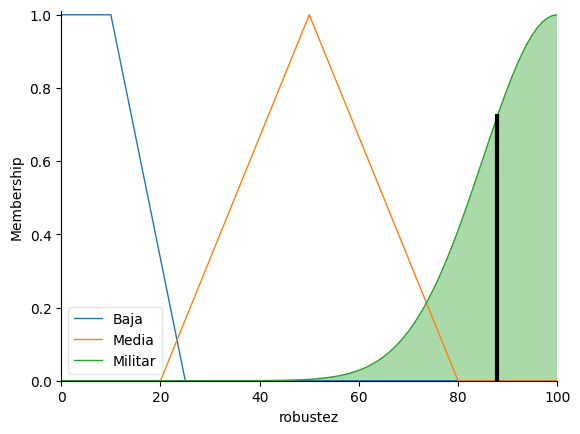

In [1]:
# ============================================================
# REQUERIMIENTO: Importar las bibliotecas necesarias para implementar
# un sistema de lógica difusa usando Scikit-Fuzzy.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl  # Módulo para definir variables lingüísticas, funciones de pertenencia, reglas e inferencia difusa


# ============================================================
# REQUERIMIENTO: Definir el universo del discurso para cada variable difusa.
# - Recursos: porcentaje entre 0 y 100.
# - Sensibilidad: escala entre 0 y 10.
# - Robustez: porcentaje entre 0 y 100.
# ============================================================

Porcentaje_recursos = np.arange(0, 101, 1)
Porcetanje_sensibilidad = np.arange(0, 11, 1)
Porentaje_robustez = np.arange(0, 101, 1)


# ============================================================
# REQUERIMIENTO: Definir al menos 3 variables difusas del dominio.
# En este sistema se definen:
# - recursos: variable de entrada / antecedente.
# - sensibilidad: variable de entrada / antecedente.
# - robustez: variable de salida / consecuente.
# ============================================================

recursos = ctrl.Antecedent(Porcentaje_recursos, 'recursos')
sensibilidad = ctrl.Antecedent(Porcetanje_sensibilidad, 'sensibilidad')
robustez = ctrl.Consequent(Porentaje_robustez, 'robustez')


# ============================================================
# REQUERIMIENTO: Implementar un proceso de defuzzificación justificado.
# Se selecciona el método del centroide porque calcula un valor numérico
# representativo considerando toda el área del conjunto difuso de salida.
# ============================================================

robustez.defuzzify_method = 'centroid'


# ============================================================
# REQUERIMIENTO: Para la variable difusa "recursos", definir mínimo
# 3 valores difusos y asociarles funciones de pertenencia.
#
# También se cumple el requisito de incluir distintos tipos de funciones:
# - Bajo: función trapezoidal.
# - Medio: función triangular.
# - Alto: función Gaussiana.
# ============================================================

Bajo = fuzz.trapmf(recursos.universe, [0, 0, 25, 50])
Medio = fuzz.trimf(recursos.universe, [25, 50, 75])
Alto = fuzz.gaussmf(recursos.universe, 100, 25)


# ============================================================
# REQUERIMIENTO: Para la variable difusa "sensibilidad", definir mínimo
# 3 valores difusos y asociarles funciones de pertenencia.
#
# También se vuelve a evidenciar el uso de:
# - Pública: función trapezoidal.
# - Confidencial: función triangular.
# - Secreta: función Gaussiana.
# ============================================================

Publica = fuzz.trapmf(sensibilidad.universe, [0, 0, 2, 4])
Confidencial = fuzz.trimf(sensibilidad.universe, [2, 4, 6])
Secreta = fuzz.gaussmf(sensibilidad.universe, 8, 2.5)


# ============================================================
# REQUERIMIENTO: Para la variable difusa de salida "robustez",
# definir mínimo 3 valores difusos y asociarles funciones de pertenencia.
#
# Se definen:
# - Baja: función trapezoidal.
# - Media: función triangular.
# - Militar: función Gaussiana.
# ============================================================

Baja = fuzz.trapmf(Porentaje_robustez, [0, 0, 10, 25])
Media = fuzz.trimf(Porentaje_robustez, [20, 50, 80])
Militar = fuzz.gaussmf(Porentaje_robustez, 100, 15)


# ============================================================
# REQUERIMIENTO: Hacer uso de dos casos de modificadores difusos.
#
# Modificador 1:
# - "Muy secreta" se obtiene elevando al cuadrado la pertenencia de "Secreta".
# - Fórmula aplicada: μ_muy A(x) = [μ_A(x)]²
#
# Modificador 2:
# - "Ligeramente bajo" se obtiene aplicando raíz cuadrada a la pertenencia de "Bajo".
# - Fórmula aplicada: μ_ligeramente A(x) = sqrt(μ_A(x))
# ============================================================

MUy_secreta = np.power(Secreta, 2)
Ligeramente_bajo = np.sqrt(Bajo)


# ============================================================
# REQUERIMIENTO: Registrar los valores lingüísticos y sus funciones de
# pertenencia dentro de cada variable difusa del sistema de control.
#
# Esto permite que las etiquetas puedan ser usadas posteriormente
# en las reglas difusas.
# ============================================================

recursos['Bajo'] = Bajo
recursos['Medio'] = Medio
recursos['Alto'] = Alto
recursos['Ligeramente_bajo'] = Ligeramente_bajo

sensibilidad['Publica'] = Publica
sensibilidad['Confidencial'] = Confidencial
sensibilidad['Secreta'] = Secreta
sensibilidad['Muy_secreta'] = MUy_secreta

robustez['Baja'] = Baja
robustez['Media'] = Media
robustez['Militar'] = Militar


# ============================================================
# REQUERIMIENTO: Definir al menos 9 reglas difusas.
#
# Además, las reglas deben incluir los operadores:
# - Intersección / AND: operador &
# - Complemento / NOT: operador ~
# - Unión / OR: operador |
#
# Las reglas 1 a 7 usan principalmente AND.
# La regla 6 incluye complemento o negación.
# La regla 9 incluye unión u OR.
# ============================================================

# Regla con operador AND:
# Si los recursos son altos Y la sensibilidad es pública,
# entonces la robustez requerida es baja.
Regla1 = ctrl.Rule(recursos['Alto'] & sensibilidad['Publica'], robustez['Baja'])

# Regla con operador AND:
# Si los recursos son medios Y la sensibilidad es pública,
# entonces la robustez requerida es media.
Regla2 = ctrl.Rule(recursos['Medio'] & sensibilidad['Publica'], robustez['Media'])

# Regla con operador AND:
# Si los recursos son bajos Y la sensibilidad es pública,
# entonces la robustez requerida es media.
Regla3 = ctrl.Rule(recursos['Bajo'] & sensibilidad['Publica'], robustez['Media'])

# Regla con operador AND:
# Si los recursos son medios Y la sensibilidad es confidencial,
# entonces la robustez requerida es media.
Regla4 = ctrl.Rule(recursos['Medio'] & sensibilidad['Confidencial'], robustez['Media'])

# Regla con operador AND:
# Si los recursos son bajos Y la sensibilidad es confidencial,
# entonces la robustez requerida es militar.
Regla5 = ctrl.Rule(recursos['Bajo'] & sensibilidad['Confidencial'], robustez['Militar'])

# Regla con operador AND y complemento / negación:
# Si la sensibilidad es secreta Y los recursos NO son altos,
# entonces la robustez requerida es militar.
Regla6 = ctrl.Rule(sensibilidad['Secreta'] & ~recursos['Alto'], robustez['Militar'])

# Regla con operador AND:
# Si los recursos son altos Y la sensibilidad es secreta,
# entonces la robustez requerida es media.
Regla7 = ctrl.Rule(recursos['Alto'] & sensibilidad['Secreta'], robustez['Media'])

# Regla basada en modificador difuso:
# Si la sensibilidad es muy secreta,
# entonces la robustez requerida es militar.
Regla8 = ctrl.Rule(sensibilidad['Muy_secreta'], robustez['Militar'])

# Regla con operador OR y uso de modificadores difusos:
# Si los recursos son ligeramente bajos O la sensibilidad es muy secreta,
# entonces la robustez requerida es militar.
Regla9 = ctrl.Rule(recursos['Ligeramente_bajo'] | sensibilidad['Muy_secreta'], robustez['Militar'])


# ============================================================
# REQUERIMIENTO: Construir el sistema de inferencia difusa usando
# las 9 reglas definidas anteriormente.
# ============================================================

sistema_control = ctrl.ControlSystem([
    Regla1,
    Regla2,
    Regla3,
    Regla4,
    Regla5,
    Regla6,
    Regla7,
    Regla8,
    Regla9
])


# ============================================================
# REQUERIMIENTO: Crear una simulación del sistema de control difuso
# para poder ingresar valores concretos y realizar la inferencia.
# ============================================================

simulacion = ctrl.ControlSystemSimulation(sistema_control)


# ============================================================
# REQUERIMIENTO: Asignar valores de entrada al sistema difuso.
#
# Caso de prueba:
# - recursos = 10
# - sensibilidad = 9
#
# Estos valores permiten evaluar el comportamiento del sistema
# y evidenciar la activación de reglas difusas.
# ============================================================

simulacion.input['recursos'] = 10
simulacion.input['sensibilidad'] = 9


# ============================================================
# REQUERIMIENTO: Ejecutar el proceso de inferencia difusa.
#
# En esta etapa Scikit-Fuzzy evalúa las reglas activadas,
# agrega las salidas difusas y aplica posteriormente la defuzzificación.
# ============================================================

simulacion.compute()


# ============================================================
# REQUERIMIENTO: Obtener y mostrar el resultado defuzzificado.
#
# Como se configuró previamente el método "centroid",
# el resultado corresponde al centroide del conjunto difuso de salida.
# ============================================================

resultado_robustez = simulacion.output['robustez']
print(f"La robustez requerida es: {resultado_robustez:.2f}%")


# ============================================================
# REQUERIMIENTO COMPLEMENTARIO: Clasificar el resultado numérico
# obtenido después de la defuzzificación en una etiqueta lingüística.
#
# Esta parte no es obligatoria en el enunciado, pero ayuda a interpretar
# el porcentaje final de robustez.
# ============================================================

def clasificar_robustez(valor):

    if valor < 30:
        return "Baja"
    elif valor < 70:
        return "Media"
    else:
        return "Militar"


# ============================================================
# REQUERIMIENTO COMPLEMENTARIO: Mostrar la clasificación lingüística
# del resultado obtenido.
# ============================================================

nivel_robustez = clasificar_robustez(resultado_robustez)

print("Nivel de robustez clasificado:", nivel_robustez)


# ============================================================
# REQUERIMIENTO COMPLEMENTARIO: Visualizar gráficamente la salida
# del sistema difuso después de la simulación.
#
# Esto permite evidenciar el conjunto difuso de salida y el valor
# defuzzificado obtenido mediante el método del centroide.
# ============================================================

robustez.view(sim=simulacion)